In [1]:
# Predictive Machine Learning Models
## MSc Data Analytics – Predictive Analytics and Machine Learning

#This notebook contains the full Python implementation for:
#1. Decision Tree Classification
#2. K-Means Clustering
#3. Regression Analysis


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

In [3]:
## Task 1: Decision Tree Classification
## Objective:
#To analyse wine purchasing decisions using entropy, information gain, and a decision tree classifier.


In [5]:
# Dataset creation
data = {
    "Price": ["m","e","e","m","m","m","e","b","b","m"],
    "Type": ["w","d","d","w","w","d","sp","r","d","d"],
    "Characteristic": ["a","t","a","sw","sw","t","a","t","a","b"],
    "Origin": ["aaa","am","am","am","eu","eu","aaa","eu","aaa","aaa"],
    "Decision": ["buy","buy","buy","buy","buy","not","not","not","not","not"]
}
df_wine = pd.DataFrame(data)
df_wine


,Price,Type,Characteristic,Origin,Decision
0,m,w,a,aaa,buy
1,e,d,t,am,buy
2,e,d,a,am,buy
3,m,w,sw,am,buy
4,m,w,sw,eu,buy
5,m,d,t,eu,not
6,e,sp,a,aaa,not
7,b,r,t,eu,not
8,b,d,a,aaa,not
9,m,d,b,aaa,not


In [6]:
# Entropy and Information Gain functions

def entropy(labels):
    values, counts = np.unique(labels, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    values, counts = np.unique(data[feature], return_counts=True)
    weighted_entropy = sum(
        (c / len(data)) * entropy(data[data[feature] == v][target])
        for v, c in zip(values, counts)
    )
    return total_entropy - weighted_entropy


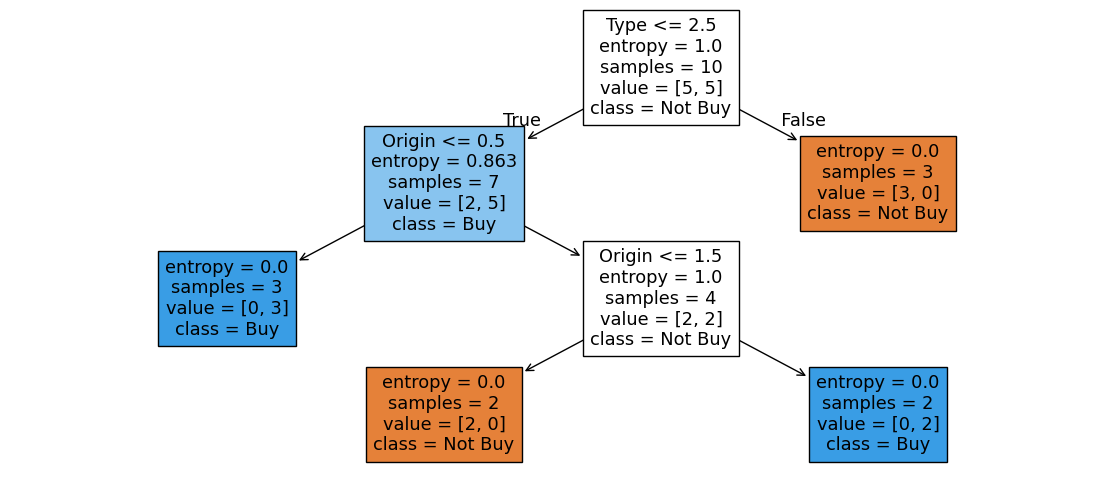

In [7]:
# Encode and train decision tree

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

encoder = LabelEncoder()
df_encoded = df_wine.apply(encoder.fit_transform)

X = df_encoded.drop("Decision", axis=1)
y = df_encoded["Decision"]

model = DecisionTreeClassifier(criterion="entropy", random_state=42)
model.fit(X, y)

plt.figure(figsize=(14,6))
plot_tree(model, feature_names=X.columns, class_names=["Not Buy","Buy"], filled=True)
plt.show()


In [10]:
## Task 2: K-Means Clustering
#Objective:
#To perform unsupervised segmentation using k-means clustering.


In [8]:
# Load and clean clustering data

df_raw = pd.read_csv("Task2_Data_Clustering.txt", header=None)
df_values = df_raw.iloc[:, 0:4]
df_clean = df_values.astype(str).replace({"array": "", r"\[|\]|\(|\)": ""}, regex=True)
df_clean = df_clean.astype(float)
df_clean.columns = ["Feature_1","Feature_2","Feature_3","Feature_4"]


In [9]:
# Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)


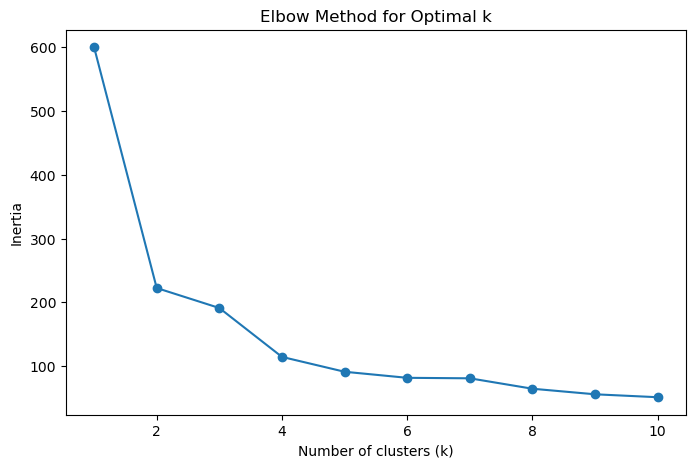

In [10]:
# Elbow method visualization

inertia = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()


In [11]:
# Final clustering

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)


In [12]:
df_clustered = df_clean.copy()
df_clustered["Cluster"] = labels
df_clustered.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,2
2,4.7,3.2,1.3,0.2,2
3,4.6,3.1,1.5,0.2,2
4,5.0,3.6,1.4,0.2,1


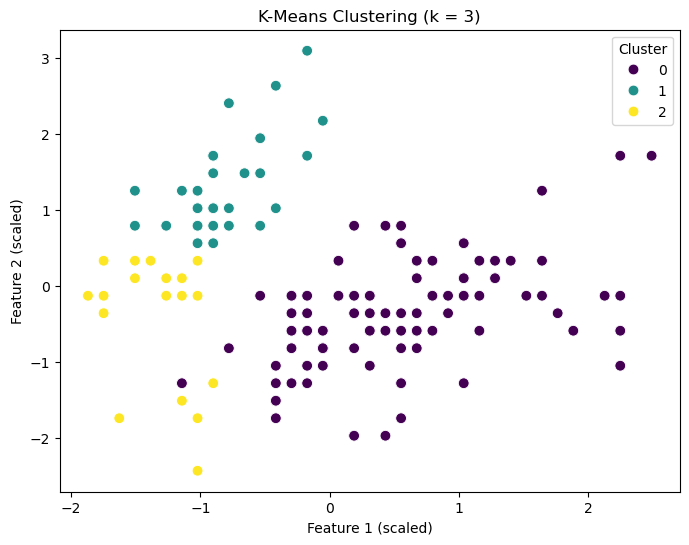

In [13]:
#Visualizaion

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=labels,
    palette="viridis",
    s=60
)

plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.title("K-Means Clustering (k = 3)")
plt.legend(title="Cluster")
plt.show()


In [14]:
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=["Feature_1", "Feature_2", "Feature_3", "Feature_4"]
)

centroids_df

,Feature_1,Feature_2,Feature_3,Feature_4
0,6.314583,2.895833,4.973958,1.703125
1,5.169697,3.630303,1.493939,0.272727
2,4.747619,2.895238,1.757143,0.352381


In [25]:
## Task 3: Regression Analysis
#Objective:
#To analyse the relationship between portfolio returns and risk.


In [15]:
# Load dataset

df_reg = pd.read_csv("Task3_Data_Process.csv")


In [16]:
X = df_reg[["x"]].values
y = df_reg["y"].values

In [30]:
df_reg.head()

,x,y
0,0.287578,1.164440
1,0.788305,-0.887802
2,0.408977,0.174131
3,0.883017,-0.217437
4,0.940467,-0.076454


In [17]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       25 non-null     float64
 1   y       25 non-null     float64
dtypes: float64(2)
memory usage: 532.0 bytes


In [18]:
df_reg.describe()

,x,y
count,25.000000,25.000000
mean,0.595560,-0.237362
std,0.300524,0.683736
min,0.042060,-1.959128
25%,0.408977,-0.647906
50%,0.640507,-0.393132
75%,0.889539,0.174131
max,0.994270,1.239426


In [19]:
# Polynomial regression

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)
y_pred = model.predict(X_poly)


In [20]:
# Evaluation

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
mse, r2


(0.2823935553636904, 0.3707736336981077)

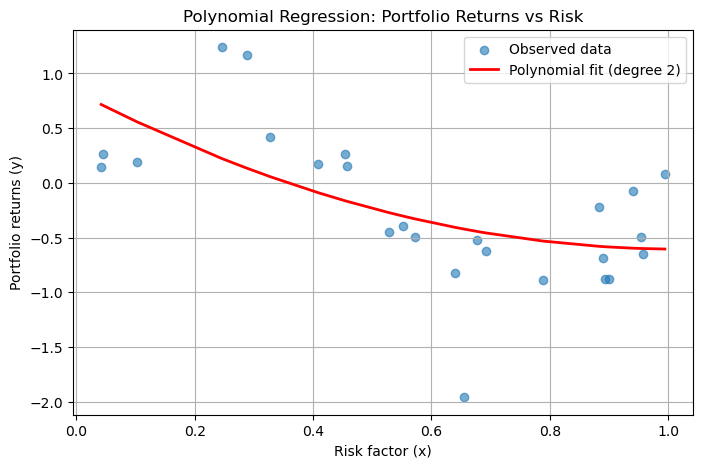

In [21]:
# Visualisation: Polynomial Regression Fit

# Sort values for smooth curve
idx = X[:, 0].argsort()
X_sorted = X[idx]
y_sorted = y[idx]
y_pred_sorted = y_pred[idx]

plt.figure(figsize=(8, 5))

# Observed data
plt.scatter(
    X, 
    y, 
    label="Observed data", 
    alpha=0.6
)

# Fitted polynomial curve
plt.plot(
    X_sorted, 
    y_pred_sorted, 
    color="red", 
    linewidth=2, 
    label="Polynomial fit (degree 2)"
)

plt.xlabel("Risk factor (x)")
plt.ylabel("Portfolio returns (y)")
plt.title("Polynomial Regression: Portfolio Returns vs Risk")
plt.legend()
plt.grid(True)
plt.show()


